In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap

# Define the grid size
grid_size = 100
num_frames = 60  # Number of time frames

# Create the grid
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
X, Y = np.meshgrid(x, y)

# Parameters of the Gaussian kernel
sigma = 0.4  # Width of the Gaussian

# Define the movement path for the center (from left-bottom to right-bottom)
center_path_x = np.linspace(0, 1, num_frames)
center_path_y = np.zeros(num_frames) + 0.1  # Keeps the kernel near the bottom

# Initialize the 3D matrix (grid_size x grid_size x num_frames)
matrix_3d = np.zeros((grid_size, grid_size, num_frames))

# Function to generate a 2D Gaussian
def gaussian_2d(X, Y, x0, y0, sigma):
    """Generate a 2D Gaussian."""
    return np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# Populate the 3D matrix with the Gaussian kernel values across time
for t in range(num_frames):
    center_x = center_path_x[t]
    center_y = center_path_y[t]
    matrix_3d[:, :, t] = gaussian_2d(X, Y, center_x, center_y, sigma)

# Create the figure and axis for animation






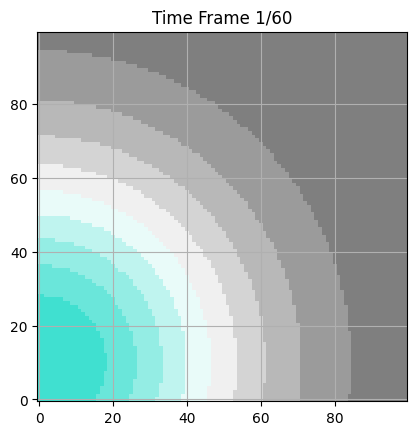

In [5]:

fig, ax = plt.subplots()


# Create a custom colormap
colors = [(0.5, 0.5, 0.5),(1, 1, 1), (64/255, 224/255, 208/255)]  # Teal to gray
n_bins = 10  # Discretizes the interpolation into bins
cmap_name = 'custom_teal_gray'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

def update(frame):
    ax.clear()
    ax.imshow(matrix_3d[:, :, frame], cmap=cm, origin='lower')
    ax.set_title(f"Time Frame {frame + 1}/{num_frames}")
    ax.grid('on')

# Create the animation
anim = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Save the animation as a GIF
gif_path = '/mnt/data/gaussian_movement.gif'
anim.save('gaussian_movement.gif''', writer=PillowWriter(fps=10))

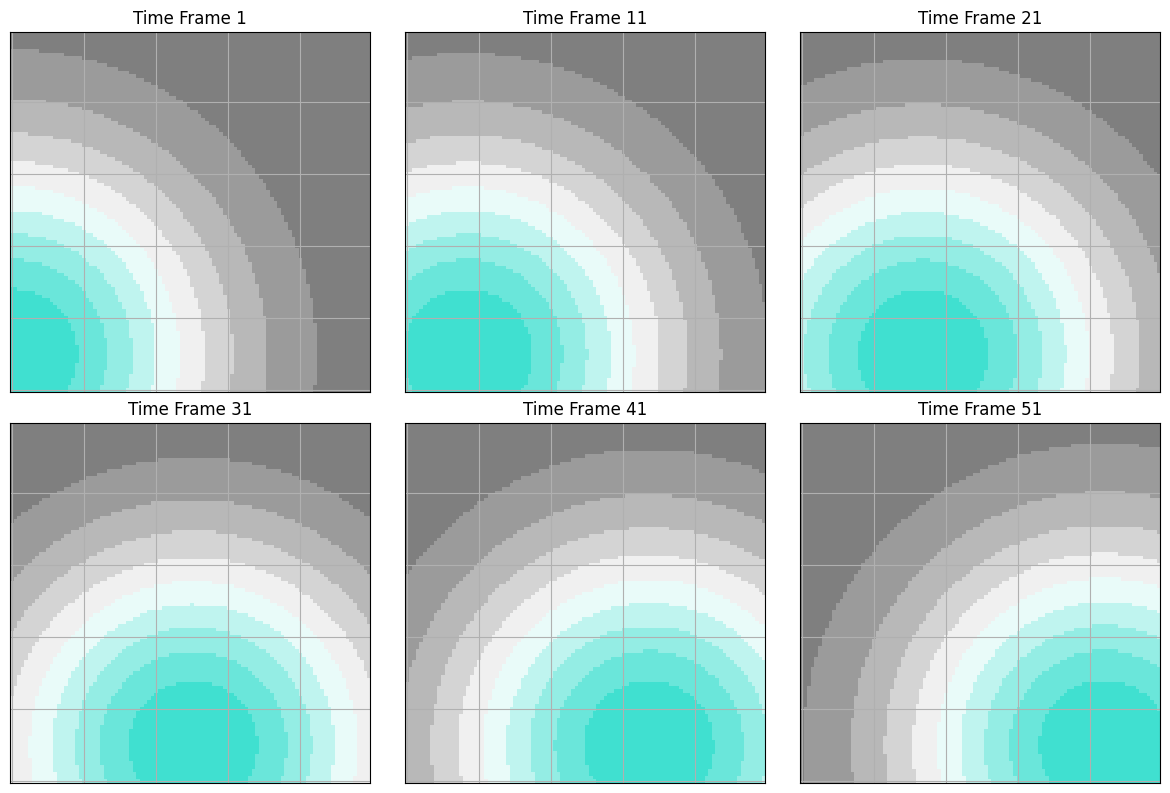

In [6]:

# Create subplots showing the Gaussian kernel at every 10th time frame
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
time_frames = range(0, num_frames, 10)

for ax, t in zip(axs.flat, time_frames):
   
    ax.imshow(matrix_3d[:, :, t], cmap=cm, origin='lower')
    ax.set_title(f'Time Frame {t + 1}')
    ax.grid(True)
    # Hide x and y ticks, labels, and numbers
    ax.tick_params(axis='both', which='both', length=0)  # This removes the ticks but keeps the grid
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels
    ax.set_xlabel('')  # Remove x-axis title
    ax.set_ylabel('')  # Remove y-axis title
        


plt.tight_layout()

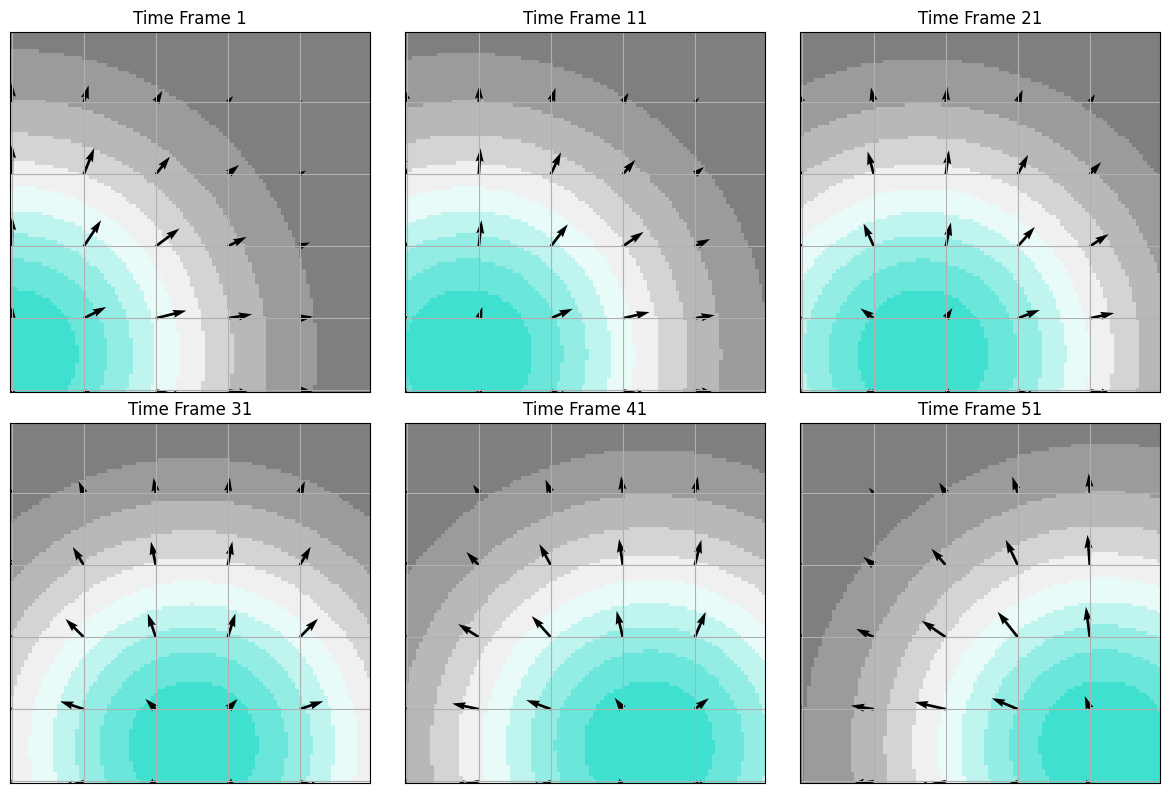

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Assuming matrix_3d, cm, and other variables are already defined as per your previous code

# Create subplots showing the Gaussian kernel at every 10th time frame
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
time_frames = range(0, num_frames, 10)

# Window size for gradient calculation
window_size = 20

for ax, t in zip(axs.flat, time_frames):
    # Plot the Gaussian kernel
    ax.imshow(matrix_3d[:, :, t], cmap=cm, origin='lower')
    ax.set_title(f'Time Frame {t + 1}')
    ax.grid(True)
    
    # Calculate the gradient
    gy, gx = np.gradient(-matrix_3d[:, :, t], axis=(0, 1))
    
    # Downsample the gradient for visualization (5x5 windows)
    gx_downsampled = gx[::window_size, ::window_size]
    gy_downsampled = gy[::window_size, ::window_size]
    
    # Create a grid for the vector field
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the vector field
    ax.quiver(X, Y, gx_downsampled, gy_downsampled, color='k')
    
    # Hide x and y ticks, labels, and numbers
    ax.tick_params(axis='both', which='both', length=0)  # This removes the ticks but keeps the grid
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels
    ax.set_xlabel('')  # Remove x-axis title
    ax.set_ylabel('')  # Remove y-axis title

plt.tight_layout()
plt.show()


In [102]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Assuming matrix_3d is a 3D array where the first two dimensions are spatial and the third is time
# For demonstration, I'll generate a simple Gaussian moving across the grid
grid_size = 100
num_frames = 60

# Define sigma as a variable (you can change this value or make it a function)
sigma_initial = grid_size / 2

# Create a 3D matrix of Gaussian data over time with a variable sigma
matrix_3d = np.zeros((grid_size, grid_size, num_frames))
for t in range(num_frames):
    x0 = t / num_frames * grid_size  # Moving center x-coordinate
    y0 = grid_size / 2  # Fixed center y-coordinate
    
    # Example: Sigma can be static or change over time. Modify as needed.
    sigma = sigma_initial + (grid_size / 50) * np.sin(2 * np.pi * t / num_frames)  # Oscillating sigma
    
    X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    matrix_3d[:, :, t] = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))




#..........................................
#.......... Circular path..............
#..........................................



# Define sigma as a variable (you can change this value)
sigma_initial = grid_size / 3

# Amplitude and frequency for the sinusoidal movement
amplitude = grid_size / 2
frequency = 2 * np.pi / num_frames

# Create a 3D matrix of Gaussian data over time with sinusoidal movement
matrix_3d = np.zeros((grid_size, grid_size, num_frames))
for t in range(num_frames):
    x0 = (grid_size / 2) + amplitude * np.sin(frequency * t)  # Sinusoidal x-coordinate
    y0 = (grid_size / 2) + amplitude * np.cos(frequency * t)  # Sinusoidal y-coordinate
    
    # Example: Sigma can be static or change over time. Modify as needed.
    sigma = sigma_initial + (grid_size / 50) * np.sin(2 * np.pi * t / num_frames)  # Oscillating sigma
    
    X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    matrix_3d[:, :, t] = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))



#..........................................
#.......... Sinosiodal path..............
#..........................................



# Define sigma as a variable (you can change this value)
sigma_initial = grid_size / 3

# Amplitude and frequency for the sinusoidal movement
amplitude = grid_size / 2
frequency = 2 * np.pi / num_frames

# Create a 3D matrix of Gaussian data over time with sinusoidal movement
matrix_3d = np.zeros((grid_size, grid_size, num_frames))
for t in range(num_frames):
    x0 = (grid_size / 2) + amplitude * np.sin(frequency * t)  # Sinusoidal x-coordinate
    y0 = (grid_size / 2) + 0.5*amplitude *np.cos(2*frequency * t)  # Sinusoidal y-coordinate
    
    # Example: Sigma can be static or change over time. Modify as needed.
    sigma = sigma_initial + (grid_size / 50) * np.sin(2 * np.pi * t / num_frames)  # Oscillating sigma
    
    X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    matrix_3d[:, :, t] = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))    


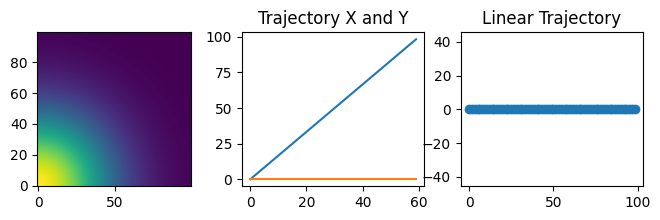

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def generate_gaussian(grid_size, num_frames, sigma_initial, trajectory_func):
    """Generate a 3D matrix of Gaussian data over time based on a trajectory function."""
    matrix_3d = np.zeros((grid_size, grid_size, num_frames))
    trajectory = np.zeros((num_frames, 2))  # To store the x0, y0 coordinates for each frame
    
    for t in range(num_frames):
        x0, y0 = trajectory_func(t, grid_size, num_frames)  # Get the trajectory
        sigma = sigma_initial + (grid_size / 50) * np.sin(2 * np.pi * t / num_frames)  # Example: Oscillating sigma
        
        X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
        matrix_3d[:, :, t] = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
        
        # Save the trajectory
        trajectory[t] = [x0, y0]
    
    return matrix_3d, trajectory

def linear_trajectory(t, grid_size, num_frames):
    """Linear trajectory function."""
    x0 = t / num_frames * grid_size  # Moving center x-coordinate
    y0 = 0  # Fixed center y-coordinate
    return x0, y0

def circular_trajectory(t, grid_size, num_frames):
    """Circular trajectory function."""
    amplitude = grid_size / 2
    frequency = 2 * np.pi / num_frames
    x0 = (grid_size / 2) + amplitude * np.sin(frequency * t)
    y0 = (grid_size / 2) + amplitude * np.cos(frequency * t)
    return x0, y0

def sinusoidal_trajectory(t, grid_size, num_frames):
    """Sinusoidal trajectory function."""
    amplitude = grid_size / 2
    frequency = 2 * np.pi / num_frames
    x0 = (grid_size / 2) + amplitude * np.sin(frequency * t)
    y0 = (grid_size / 2) + 0.5 * amplitude * np.cos(2 * frequency * t)
    return x0, y0


def save_trajectory(trajectory, filename):
    """Save the trajectory to a file."""
    np.savetxt(filename, trajectory, delimiter=",", header="x0, y0")



grid_size = 100
num_frames = 60
sigma_initial = grid_size / 3

# Select the scenario: 'linear', 'circular', or 'sinusoidal'
scenario = 'linear'  # Change this to select the scenario

if scenario == 'linear':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, linear_trajectory)
elif scenario == 'circular':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, circular_trajectory)
elif scenario == 'sinusoidal':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, sinusoidal_trajectory)
else:
    raise ValueError("Unknown scenario: Please select 'linear', 'circular', or 'sinusoidal'")

# Save the trajectory
save_trajectory(trajectory, f"{scenario}_trajectory.csv")

# Optional: Visualization (e.g., first frame)
plt.figure(figsize=(8, 2))

plt.subplot(1, 3, 1)
plt.imshow(matrix_3d[:, :, 0], cmap='viridis', origin='lower')
plt.subplot(1, 3, 2)
plt.plot(trajectory)
plt.legend
plt.title('Trajectory X and Y')
plt.subplot(1, 3, 3)
plt.scatter(trajectory[:, 0], trajectory[:, 1])
plt.axis('equal')
plt.title(f'{scenario.capitalize()} Trajectory')
plt.show()


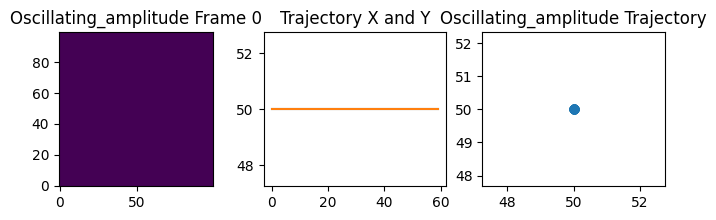

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def generate_gaussian(grid_size, num_frames, sigma_initial, trajectory_func, amplitude_func=None):
    """Generate a 3D matrix of Gaussian data over time based on a trajectory and amplitude function."""
    matrix_3d = np.zeros((grid_size, grid_size, num_frames))
    trajectory = np.zeros((num_frames, 2))  # To store the x0, y0 coordinates for each frame
    
    for t in range(num_frames):
        x0, y0 = trajectory_func(t, grid_size, num_frames)  # Get the trajectory
        sigma = sigma_initial + (grid_size / 50) * np.sin(2 * np.pi * t / num_frames)  # Example: Oscillating sigma

        # Default amplitude is 1 if not provided
        amplitude = amplitude_func(t, num_frames) if amplitude_func else 1
        
        X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
        gaussian = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
        matrix_3d[:, :, t] = amplitude * gaussian  # Modulate amplitude if provided
        
        # Save the trajectory
        trajectory[t] = [x0, y0]
    
    return matrix_3d, trajectory

def linear_trajectory(t, grid_size, num_frames):
    """Linear trajectory function."""
    x0 = t / num_frames * grid_size  # Moving center x-coordinate
    y0 = 0  # Fixed center y-coordinate
    return x0, y0

def circular_trajectory(t, grid_size, num_frames):
    """Circular trajectory function."""
    amplitude = grid_size / 2
    frequency = 2 * np.pi / num_frames
    x0 = (grid_size / 2) + amplitude * np.sin(frequency * t)
    y0 = (grid_size / 2) + amplitude * np.cos(frequency * t)
    return x0, y0

def sinusoidal_trajectory(t, grid_size, num_frames):
    """Sinusoidal trajectory function."""
    amplitude = grid_size / 2
    frequency = 2 * np.pi / num_frames
    x0 = (grid_size / 2) + amplitude * np.sin(frequency * t)
    y0 = (grid_size / 2) + 0.5 * amplitude * np.cos(2 * frequency * t)
    return x0, y0

def oscillating_amplitude_trajectory(t, grid_size, num_frames):
    """Fixed center trajectory with oscillating amplitude."""
    x0, y0 = grid_size / 2, grid_size / 2  # Fixed center
    return x0, y0

def oscillating_amplitude(t, num_frames):
    """Amplidtue function that oscillates between -1 and 1."""
    return np.sin(10*2 * np.pi * t / num_frames)  # Oscillates between -1 and 1

def save_trajectory(trajectory, filename):
    """Save the trajectory to a file."""
    np.savetxt(filename, trajectory, delimiter=",", header="x0, y0")

# Parameters
grid_size = 100
num_frames = 60
sigma_initial = grid_size / 3

# Select the scenario: 'linear', 'circular', 'sinusoidal', or 'oscillating_amplitude'
scenario = 'oscillating_amplitude'  # Change this to select the scenario

if scenario == 'linear':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, linear_trajectory)
elif scenario == 'circular':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, circular_trajectory)
elif scenario == 'sinusoidal':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, sinusoidal_trajectory)
elif scenario == 'oscillating_amplitude':
    matrix_3d, trajectory = generate_gaussian(grid_size, num_frames, sigma_initial, oscillating_amplitude_trajectory, oscillating_amplitude)
else:
    raise ValueError("Unknown scenario: Please select 'linear', 'circular', 'sinusoidal', or 'oscillating_amplitude'")

# Save the trajectory
save_trajectory(trajectory, f"{scenario}_trajectory.csv")

# Optional: Visualization (e.g., first frame)
plt.figure(figsize=(8, 2))

plt.subplot(1, 3, 1)
plt.imshow(matrix_3d[:, :, 0], cmap='viridis', origin='lower')
plt.title(f'{scenario.capitalize()} Frame 0')

plt.subplot(1, 3, 2)
plt.plot(trajectory)
plt.title('Trajectory X and Y')

plt.subplot(1, 3, 3)
plt.scatter(trajectory[:, 0], trajectory[:, 1])
plt.axis('equal')
plt.title(f'{scenario.capitalize()} Trajectory')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/quiver.py:645: RuntimeWarning: divide by zero encountered in double_scalars
  length = a * (widthu_per_lenu / (self.scale * self.width))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/quiver.py:645: RuntimeWarning: divide by zero encountered in double_scalars
  length = a * (widthu_per_lenu / (self.scale * self.width))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


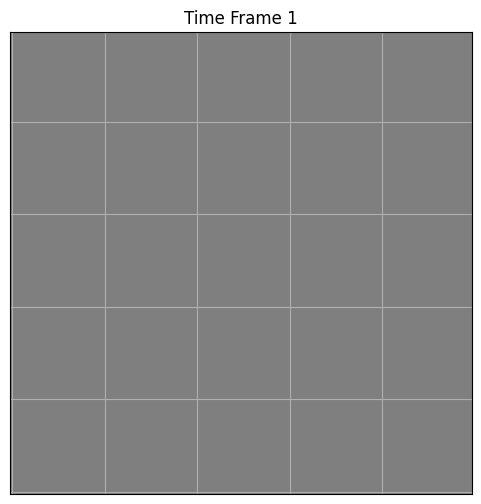

In [66]:

# Create the figure for animation
fig, ax = plt.subplots(figsize=(6, 6))

window_size = 20
# Create a custom colormap
colors = [(0.5, 0.5, 0.5),(1, 1, 1), (64/255, 224/255, 208/255)]  # Teal to gray
n_bins = 50  # Discretizes the interpolation into bins
cmap_name = 'custom_teal_gray'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

def update(t):
    ax.clear()  # Clear the previous frame
    current_matrix = matrix_3d[:, :, t]
    
    # Plot the Gaussian kernel
    ax.imshow(current_matrix, cmap=cm, origin='lower')
    ax.set_title(f'Time Frame {t + 1}')
    ax.grid(True)
    
    # Calculate the gradient
    gy, gx = np.gradient(-current_matrix, axis=(0, 1))
    
    # Downsample the gradient for visualization (window_size x window_size)
    gx_downsampled = gx[::window_size, ::window_size]
    gy_downsampled = gy[::window_size, ::window_size]
    
    # Create a grid for the vector field
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the vector field
    ax.quiver(X, Y, gx_downsampled, gy_downsampled, color='k')
    
    # Hide x and y ticks, labels, and numbers
    ax.tick_params(axis='both', which='both', length=0)  # This removes the ticks but keeps the grid
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels
    ax.set_xlabel('')  # Remove x-axis title
    ax.set_ylabel('')  # Remove y-axis title


# Create the animation
anim = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Save the animation as a GIF
anim.save('gaussian_vector_field_animation.gif', writer=PillowWriter(fps=10))



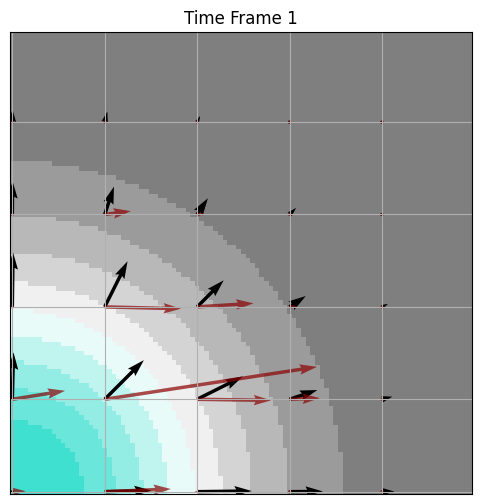

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap

# Assuming matrix_3d, grid_size, num_frames are already defined

# Create the figure for animation
fig, ax = plt.subplots(figsize=(6, 6))

window_size = 20
# Create a custom colormap
colors = [(0.5, 0.5, 0.5),(1, 1, 1), (64/255, 224/255, 208/255)]  # Teal to gray
n_bins = 10  # Discretizes the interpolation into bins
cmap_name = 'custom_teal_gray'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

def update(t):
    ax.clear()  # Clear the previous frame
    current_matrix = matrix_3d[:, :, t]
    
    # Plot the Gaussian kernel
    ax.imshow(current_matrix, cmap=cm, origin='lower')
    ax.set_title(f'Time Frame {t + 1}')
    ax.grid(True)
    
    # Calculate the gradient
    gy, gx = np.gradient(-current_matrix, axis=(0, 1))
    
    # Downsample the gradient for visualization (window_size x window_size)
    gx_downsampled = gx[::window_size, ::window_size]
    gy_downsampled = gy[::window_size, ::window_size]
    
    # Create a grid for the vector field
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the gradient vector field
    ax.quiver(X, Y, gx_downsampled, gy_downsampled, color='k')
    
    # Calculate optical flow between the current and next frames
    if t < num_frames - 1:
        frame1 = matrix_3d[:, :, t].astype(np.float32)
        frame2 = matrix_3d[:, :, t + 1].astype(np.float32)
        flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        flow_x = flow[..., 0]
        flow_y = flow[..., 1]
        
        # Downsample the optical flow for visualization
        flow_x_downsampled = flow_x[::window_size, ::window_size]
        flow_y_downsampled = flow_y[::window_size, ::window_size]
        
        # Plot the optical flow vector field
        ax.quiver(X, Y, flow_x_downsampled, flow_y_downsampled, color='darkred', alpha=0.7)
    
    # Hide x and y ticks, labels, and numbers
    ax.tick_params(axis='both', which='both', length=0)  # This removes the ticks but keeps the grid
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels
    ax.set_xlabel('')  # Remove x-axis title
    ax.set_ylabel('')  # Remove y-axis title

# Create the animation
anim = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Save the animation as a GIF
anim.save('gaussian_vector_field_OpticalVSGradeintFlow.gif', writer=PillowWriter(fps=10))


/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/2060651125.py:99: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axs[3].plot(time_frames, momentary_optical_directions, 'r-', label='Optical Flow', color='darkred')
/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/2060651125.py:100: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  axs[3].plot(time_frames, momentary_gradient_directions, 'k-', label='Gradient Flow', color='black')
/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/2060651125.py:99: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axs[3].plot(time_frames, momentary_optical_directions, 'r-', label='Optical 

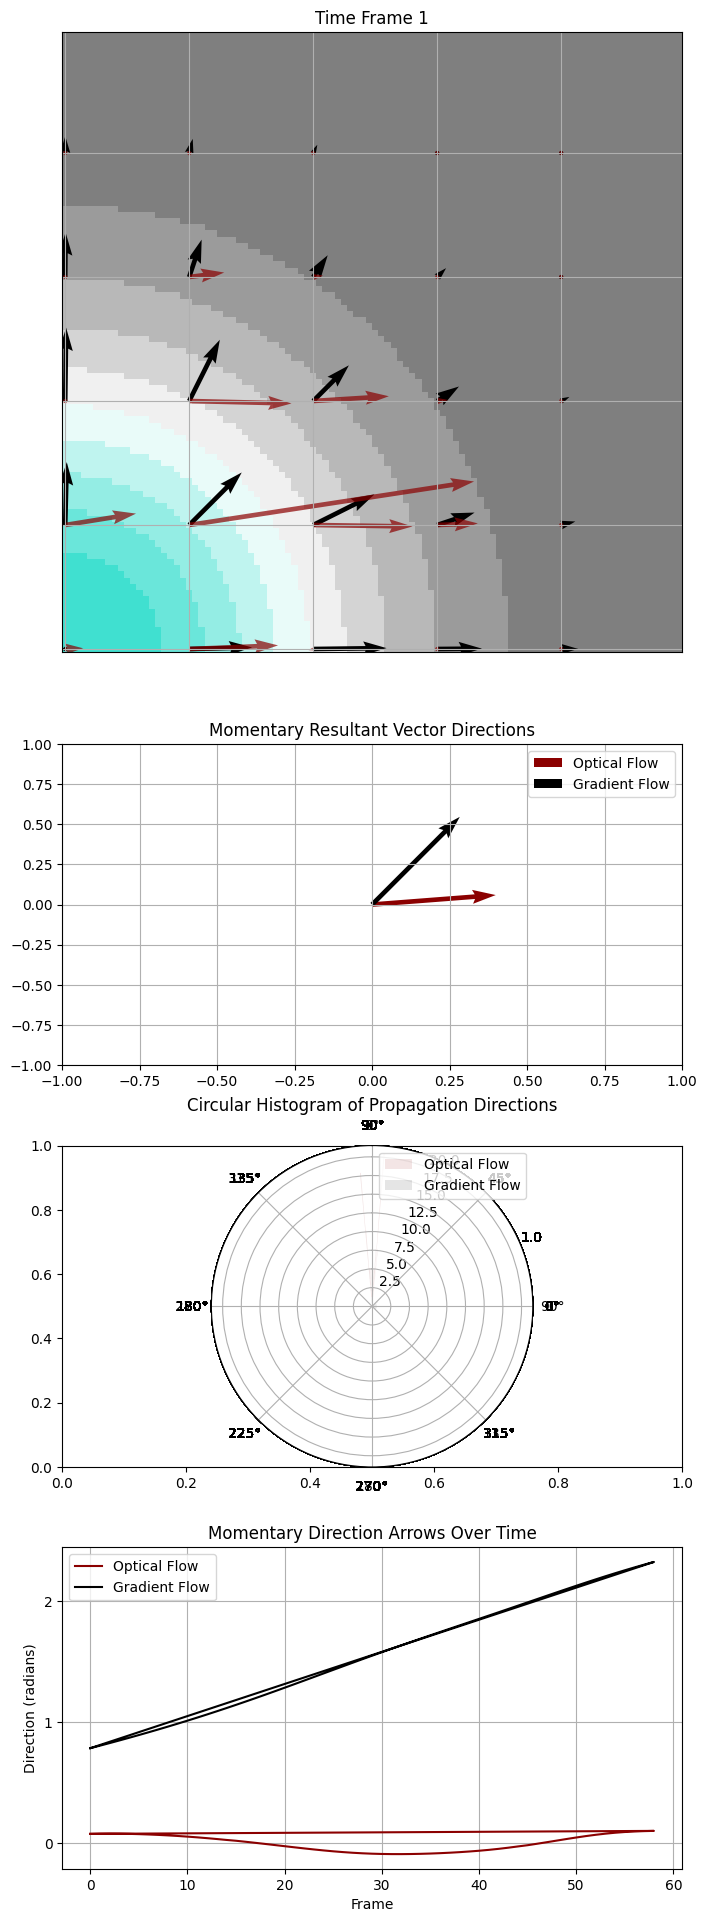

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

# Assuming matrix_3d, grid_size, num_frames are already defined

# Create the figure for animation with 4 subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 24), gridspec_kw={'height_ratios': [2, 1, 1, 1]})

window_size = 20
# Create a custom colormap
colors = [(0.5, 0.5, 0.5), (1, 1, 1), (64/255, 224/255, 208/255)]  # Teal to gray
n_bins = 10  # Discretizes the interpolation into bins
cmap_name = 'custom_teal_gray'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Arrays to store the momentary direction vectors
momentary_optical_directions = []
momentary_gradient_directions = []
time_frames = []

def update(t):
    for ax in axs:
        ax.clear()  # Clear the previous frame

    current_matrix = matrix_3d[:, :, t]
    
    # Plot the Gaussian kernel on the first subplot
    axs[0].imshow(current_matrix, cmap=cm, origin='lower')
    axs[0].set_title(f'Time Frame {t + 1}')
    axs[0].grid(True)
    
    # Calculate the gradient
    gy, gx = np.gradient(-current_matrix, axis=(0, 1))
    
    # Downsample the gradient for visualization (window_size x window_size)
    gx_downsampled = gx[::window_size, ::window_size]
    gy_downsampled = gy[::window_size, ::window_size]
    
    # Create a grid for the vector field
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the gradient vector field
    axs[0].quiver(X, Y, gx_downsampled, gy_downsampled, color='k')
    
    # Calculate optical flow between the current and next frames
    if t < num_frames - 1:
        frame1 = matrix_3d[:, :, t].astype(np.float32)
        frame2 = matrix_3d[:, :, t + 1].astype(np.float32)
        flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        flow_x = flow[..., 0]
        flow_y = flow[..., 1]
        
        # Downsample the optical flow for visualization
        flow_x_downsampled = flow_x[::window_size, ::window_size]
        flow_y_downsampled = flow_y[::window_size, ::window_size]
        
        # Plot the optical flow vector field
        axs[0].quiver(X, Y, flow_x_downsampled, flow_y_downsampled, color='darkred', alpha=0.7)
        
        # Calculate momentary resultant vectors
        resultant_flow_x = np.mean(flow_x)
        resultant_flow_y = np.mean(flow_y)
        resultant_grad_x = np.mean(gx)
        resultant_grad_y = np.mean(gy)
        
        # Calculate the angles for the resultant vectors
        angle_optical_flow = np.arctan2(resultant_flow_y, resultant_flow_x)
        angle_gradient = np.arctan2(resultant_grad_y, resultant_grad_x)
        
        # Store the angles for the histogram plot and time frames for the direction plot
        momentary_optical_directions.append(angle_optical_flow)
        momentary_gradient_directions.append(angle_gradient)
        time_frames.append(t)

        # Plot the momentary resultant vector directions in a polar plot
        axs[1].quiver(0, 0, np.cos(angle_optical_flow), np.sin(angle_optical_flow), color='darkred', scale=5, label='Optical Flow')
        axs[1].quiver(0, 0, np.cos(angle_gradient), np.sin(angle_gradient), color='black', scale=5, label='Gradient Flow')
        axs[1].set_xlim(-1, 1)
        axs[1].set_ylim(-1, 1)
        axs[1].set_title('Momentary Resultant Vector Directions')
        axs[1].legend()
        axs[1].grid(True)

    # Plot the circular histogram of propagation directions in the third subplot
    bin_count = 30
    axs[2] = plt.subplot(413, projection='polar')
    axs[2].hist(momentary_optical_directions, bins=bin_count, color='darkred', alpha=0.1, label='Optical Flow', density=True)
    axs[2].hist(momentary_gradient_directions, bins=bin_count, color='black', alpha=0.1, label='Gradient Flow', density=True)
    axs[2].set_theta_zero_location('N')
    axs[2].set_theta_direction(-1)
    axs[2].set_title('Circular Histogram of Propagation Directions')
    axs[2].legend()

    # Plot the momentary direction arrows over time
    axs[3].plot(time_frames, momentary_optical_directions, 'r-', label='Optical Flow', color='darkred')
    axs[3].plot(time_frames, momentary_gradient_directions, 'k-', label='Gradient Flow', color='black')
    axs[3].set_title('Momentary Direction Arrows Over Time')
    axs[3].set_xlabel('Frame')
    axs[3].set_ylabel('Direction (radians)')
    axs[3].legend()
    axs[3].yaxis.set_major_locator(MaxNLocator(integer=True))
    axs[3].grid(True)
    
    # Hide x and y ticks, labels, and numbers in the first subplot
    axs[0].tick_params(axis='both', which='both', length=0)  # This removes the ticks but keeps the grid
    axs[0].set_xticklabels([])  # Remove x-axis labels
    axs[0].set_yticklabels([])  # Remove y-axis labels
    axs[0].set_xlabel('')  # Remove x-axis title
    axs[0].set_ylabel('')

# Create the animation
anim = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Save the animation as a GIF
anim.save('gaussian_vector_field_animation.gif', writer=PillowWriter(fps=10))


/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/3402607865.py:113: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axs[3].plot(time_frames, momentary_optical_directions, 'r-', label='Optical Flow', color='darkred')
/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/3402607865.py:114: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  axs[3].plot(time_frames, momentary_gradient_directions, 'k-', label='Gradient Flow', color='black')
/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/3402607865.py:113: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axs[3].plot(time_frames, momentary_optical_directions, 'r-', label='Optica

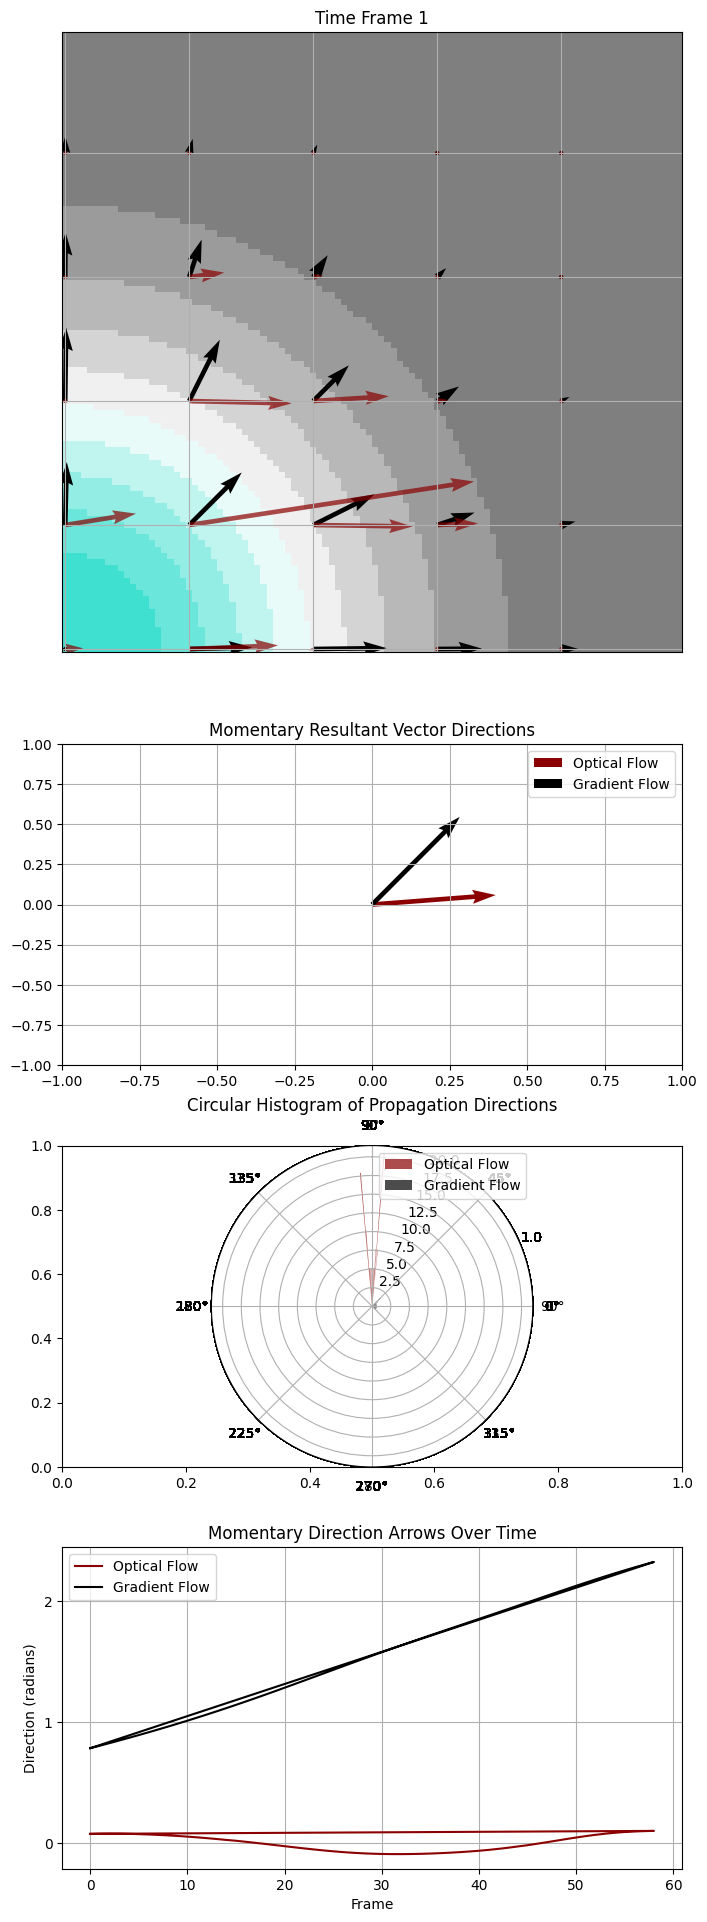

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

# Assuming matrix_3d, grid_size, num_frames are already defined

# Create the figure for animation with 4 subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 24), gridspec_kw={'height_ratios': [2, 1, 1, 1]})

window_size = 20
# Create a custom colormap
colors = [(0.5, 0.5, 0.5), (1, 1, 1), (64/255, 224/255, 208/255)]  # Teal to gray
n_bins = 10  # Discretizes the interpolation into bins
cmap_name = 'custom_teal_gray'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Arrays to store the momentary direction vectors
momentary_optical_directions = []
momentary_gradient_directions = []
time_frames = []

def update(t):
    for ax in axs:
        ax.clear()  # Clear the previous frame

    current_matrix = matrix_3d[:, :, t]
    
    # Plot the Gaussian kernel on the first subplot
    axs[0].imshow(current_matrix, cmap=cm, origin='lower')
    axs[0].set_title(f'Time Frame {t + 1}')
    axs[0].grid(True)
    
    # Calculate the gradient
    gy, gx = np.gradient(-current_matrix, axis=(0, 1))
    
    # Downsample the gradient for visualization (window_size x window_size)
    gx_downsampled = gx[::window_size, ::window_size]
    gy_downsampled = gy[::window_size, ::window_size]
    
    # Create a grid for the vector field
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the gradient vector field
    axs[0].quiver(X, Y, gx_downsampled, gy_downsampled, color='k')
    
    # Calculate optical flow between the current and next frames
    if t < num_frames - 1:
        frame1 = matrix_3d[:, :, t].astype(np.float32)
        frame2 = matrix_3d[:, :, t + 1].astype(np.float32)
        flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        flow_x = flow[..., 0]
        flow_y = flow[..., 1]
        
        # Downsample the optical flow for visualization
        flow_x_downsampled = flow_x[::window_size, ::window_size]
        flow_y_downsampled = flow_y[::window_size, ::window_size]
        
        # Plot the optical flow vector field
        axs[0].quiver(X, Y, flow_x_downsampled, flow_y_downsampled, color='darkred', alpha=0.7)
        
        # Calculate momentary resultant vectors
        resultant_flow_x = np.mean(flow_x)
        resultant_flow_y = np.mean(flow_y)
        resultant_grad_x = np.mean(gx)
        resultant_grad_y = np.mean(gy)
        
        # Calculate the angles for the resultant vectors
        angle_optical_flow = np.arctan2(resultant_flow_y, resultant_flow_x)
        angle_gradient = np.arctan2(resultant_grad_y, resultant_grad_x)
        
        # Store the angles for the histogram plot and time frames for the direction plot
        momentary_optical_directions.append(angle_optical_flow)
        momentary_gradient_directions.append(angle_gradient)
        time_frames.append(t)

        # Plot the momentary resultant vector directions in a polar plot
        axs[1].quiver(0, 0, np.cos(angle_optical_flow), np.sin(angle_optical_flow), color='darkred', scale=5, label='Optical Flow')
        axs[1].quiver(0, 0, np.cos(angle_gradient), np.sin(angle_gradient), color='black', scale=5, label='Gradient Flow')
        axs[1].set_xlim(-1, 1)
        axs[1].set_ylim(-1, 1)
        axs[1].set_title('Momentary Resultant Vector Directions')
        axs[1].legend()
        axs[1].grid(True)

    # Plot the filled circular histogram of propagation directions in the third subplot
    bin_count = 30
    axs[2] = plt.subplot(413, projection='polar')
    n_optical, bins_optical, patches_optical = axs[2].hist(
        momentary_optical_directions, bins=bin_count, color='darkred', alpha=0.7, label='Optical Flow', density=True
    )
    n_gradient, bins_gradient, patches_gradient = axs[2].hist(
        momentary_gradient_directions, bins=bin_count, color='black', alpha=0.7, label='Gradient Flow', density=True
    )

    # Fill the bins with color
    for patch in patches_optical:
        patch.set_facecolor('darkred')
        patch.set_alpha(0.7)
        
    for patch in patches_gradient:
        patch.set_facecolor('black')
        patch.set_alpha(0.7)

    axs[2].set_theta_zero_location('N')
    axs[2].set_theta_direction(-1)
    axs[2].set_title('Circular Histogram of Propagation Directions')
    axs[2].legend()

    # Plot the momentary direction arrows over time
    axs[3].plot(time_frames, momentary_optical_directions, 'r-', label='Optical Flow', color='darkred')
    axs[3].plot(time_frames, momentary_gradient_directions, 'k-', label='Gradient Flow', color='black')
    axs[3].set_title('Momentary Direction Arrows Over Time')
    axs[3].set_xlabel('Frame')
    axs[3].set_ylabel('Direction (radians)')
    axs[3].legend()
    axs[3].yaxis.set_major_locator(MaxNLocator(integer=True))
    axs[3].grid(True)
    
    # Hide x and y ticks, labels, and numbers in the first subplot
    axs[0].tick_params(axis='both', which='both', length=0)  # This removes the ticks but keeps the grid
    axs[0].set_xticklabels([])  # Remove x-axis labels
    axs[0].set_yticklabels([])  # Remove y-axis labels
    axs[0].set_xlabel('')  # Remove x-axis title
    axs[0].set_ylabel('')

# Create the animation
anim = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Save the animation as a GIF
anim.save('gaussian_vector_field_animation.gif', writer=PillowWriter(fps=10))


/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/3625169497.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  axs[0].plot(time_frames[:-1], momentary_optical_directions[:-1], 'ro-', label='Optical Flow', color='darkred')
/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_7471/3625169497.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot(time_frames[:-1], momentary_gradient_directions[:-1], 'ko-', label='Gradient Flow', color='black')


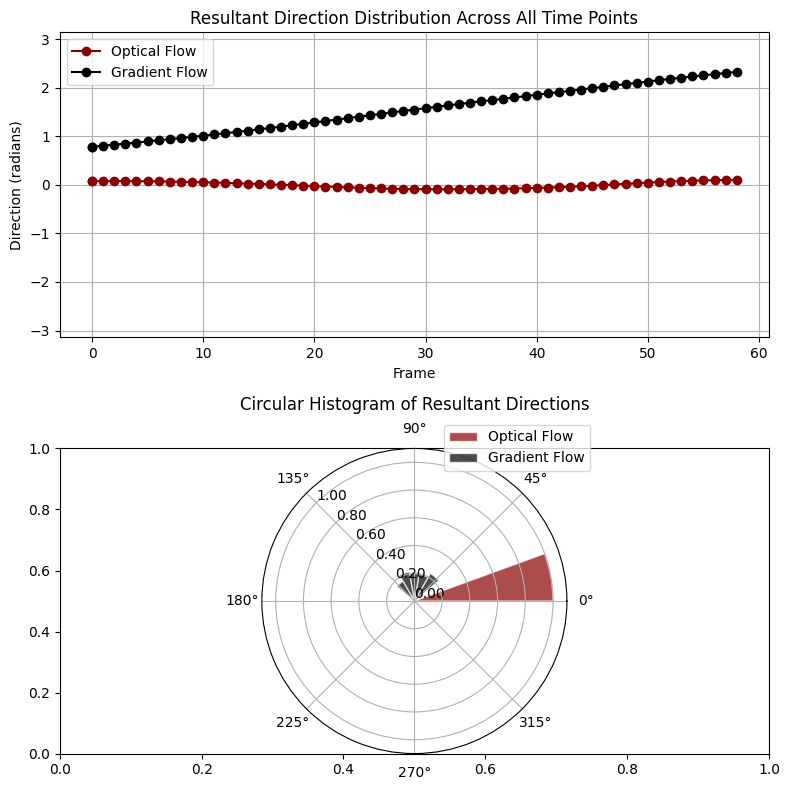

In [51]:
from matplotlib.ticker import MaxNLocator


# Set the bin width in degrees and calculate the bin edges in radians
bin_width_degrees = 20
bin_width_radians = np.deg2rad(bin_width_degrees)
bin_edges = np.arange(0, 2 * np.pi + bin_width_radians, bin_width_radians)

# Calculate probabilities for each bin
# Optical Flow
counts_optical, _ = np.histogram(momentary_optical_directions, bins=bin_edges)
probabilities_optical = counts_optical / counts_optical.sum()

# Gradient Flow
counts_gradient, _ = np.histogram(momentary_gradient_directions, bins=bin_edges)
probabilities_gradient = counts_gradient / counts_gradient.sum()

# Compute the centers of each bin for plotting
bin_centers = bin_edges[:-1] + bin_width_radians / 2

# Create a new figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# -------------------------------
# First Subplot: Resultant Directions Over Time
# -------------------------------
axs[0].plot(time_frames[:-1], momentary_optical_directions[:-1], 'ro-', label='Optical Flow', color='darkred')
axs[0].plot(time_frames[:-1], momentary_gradient_directions[:-1], 'ko-', label='Gradient Flow', color='black')
axs[0].set_title('Resultant Direction Distribution Across All Time Points')
axs[0].set_xlabel('Frame')
axs[0].set_ylabel('Direction (radians)')
axs[0].legend()
axs[0].set_ylim([-np.pi, np.pi])
axs[0].yaxis.set_major_locator(MaxNLocator(integer=True))
axs[0].grid(True)

# -------------------------------
# Second Subplot: Circular Histogram of Resultant Directions with Constant Bin Width and Probability
# -------------------------------
ax_polar = plt.subplot(212, projection='polar')

# Plot Optical Flow probabilities
bars_optical = ax_polar.bar(
    bin_centers,
    probabilities_optical,
    width=bin_width_radians,
    bottom=0.0,
    color='darkred',
    alpha=0.7,
    label='Optical Flow',
    edgecolor='white'
)

# Plot Gradient Flow probabilities
bars_gradient = ax_polar.bar(
    bin_centers,
    probabilities_gradient,
    width=bin_width_radians,
    bottom=0.0,
    color='black',
    alpha=0.7,
    label='Gradient Flow',
    edgecolor='white'
)

# Set 0 degrees on the right-hand side and 90 degrees at the top
ax_polar.set_theta_zero_location('E')  # 'E' for East (right-hand side)
ax_polar.set_theta_direction(1)       # Clockwise direction

# Set title and legend
ax_polar.set_title('Circular Histogram of Resultant Directions', va='bottom')
ax_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# Set the radial limits from 0 to the maximum probability
max_prob = max(probabilities_optical.max(), probabilities_gradient.max())
ax_polar.set_ylim(0, max_prob * 1.1)  # Add 10% padding

# Set radial ticks to show probability values
ax_polar.set_rlabel_position(135)  # Move radial labels away from overlapping
ax_polar.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='lower'))
ax_polar.set_yticks(np.linspace(0, max_prob, num=6))
ax_polar.set_yticklabels([f"{p:.2f}" for p in np.linspace(0, max_prob, num=6)])

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()


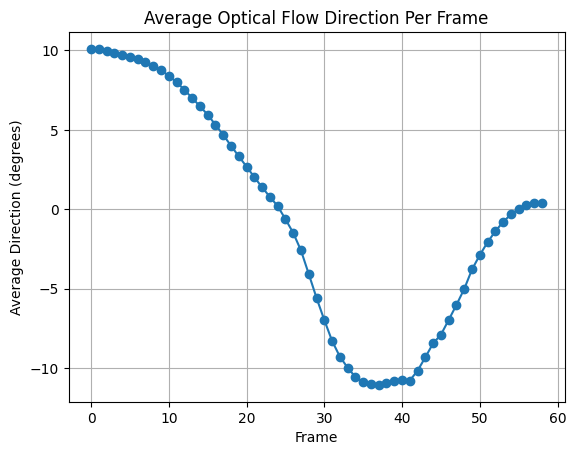

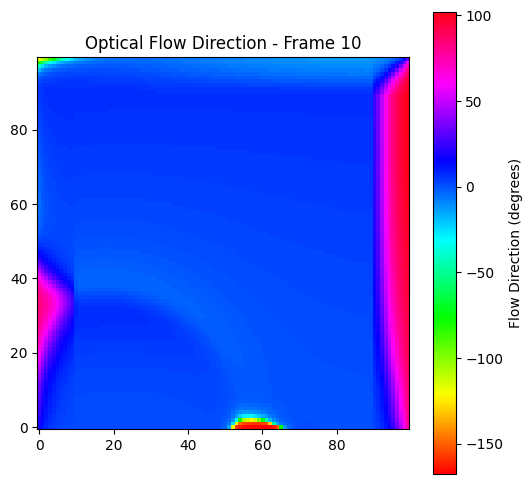

In [209]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def calculate_optical_flow_directions(matrix_3d):
    num_frames = matrix_3d.shape[2]
    
    # Initialize arrays to store the optical flow results
    flow_directions = []

    for t in range(num_frames - 1):
        # Get two consecutive frames
        frame1 = matrix_3d[:, :, t].astype(np.float32)
        frame2 = matrix_3d[:, :, t + 1].astype(np.float32)

        # Calculate optical flow between the two frames
        flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

        # Calculate the direction of the flow for each pixel
        flow_angle = np.arctan2(flow[..., 1], flow[..., 0]) * 180 / np.pi  # Angle in degrees
        
        # Store the flow directions
        flow_directions.append(flow_angle)
    
    return np.array(flow_directions)

def calculate_average_direction(flow_directions):
    num_frames = flow_directions.shape[0]
    
    # Initialize array to store the average direction per frame
    avg_directions = []

    for t in range(num_frames):
        # Get the flow directions for the current frame
        flow_angle = flow_directions[t]
        
        # Calculate the average direction (in degrees)
        avg_direction = np.mean(flow_angle)
        
        avg_directions.append(avg_direction)
    
    return np.array(avg_directions)

# Example usage
# Assuming matrix_3d is your 3D matrix with shape (grid_size, grid_size, num_frames)

# Calculate momentary optical flow directions
flow_directions = calculate_optical_flow_directions(matrix_3d)

# Calculate the average direction for each frame
avg_directions = calculate_average_direction(flow_directions)

# Display the average direction for each frame
plt.figure()
plt.plot(avg_directions, 'o-')
plt.title('Average Optical Flow Direction Per Frame')
plt.xlabel('Frame')
plt.ylabel('Average Direction (degrees)')
plt.grid(True)
plt.show()

# To visualize the flow direction at each pixel for a specific frame (e.g., frame 10):
plt.figure(figsize=(6, 6))
plt.imshow(flow_directions[10], cmap='hsv', origin='lower')
plt.colorbar(label='Flow Direction (degrees)')
plt.title('Optical Flow Direction - Frame 10')
plt.show()


'optical_flow_vs_trajectory_animation.gif'

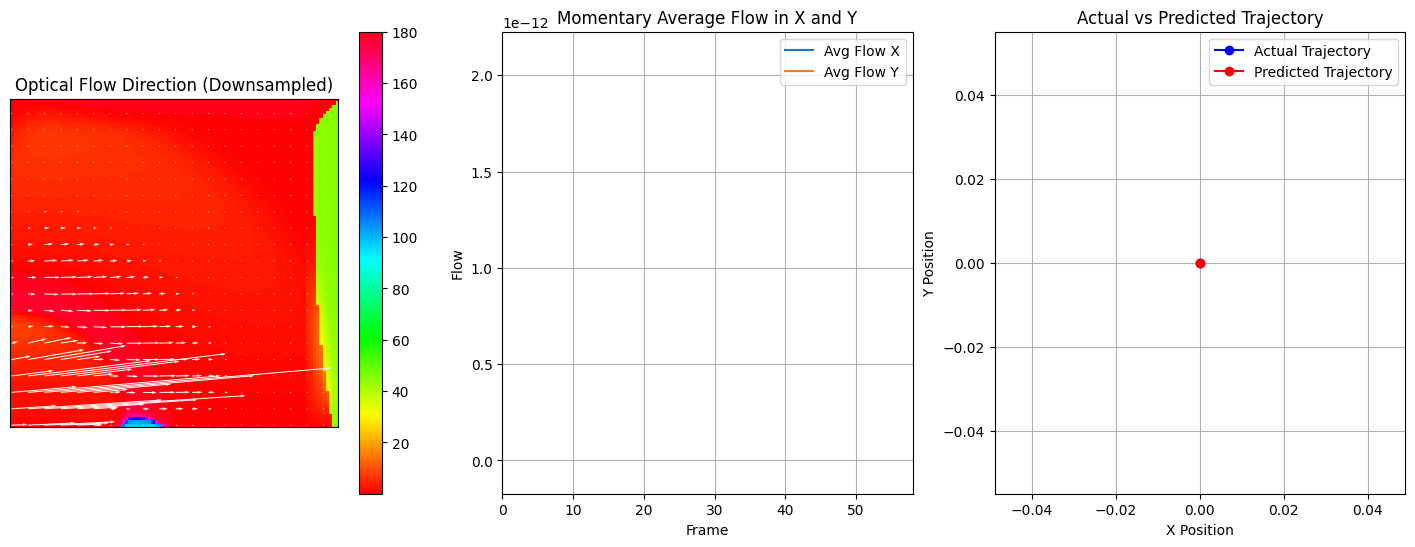

In [219]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def calculate_optical_flow(matrix_3d):
    num_frames = matrix_3d.shape[2]
    
    # Initialize arrays to store the optical flow components
    flow_x = []
    flow_y = []

    for t in range(num_frames - 1):
        # Get two consecutive frames
        frame1 = matrix_3d[:, :, t].astype(np.float32)
        frame2 = matrix_3d[:, :, t + 1].astype(np.float32)

        # Calculate optical flow between the two frames
        flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

        # Separate the flow into x and y components
        flow_x.append(flow[..., 0])
        flow_y.append(flow[..., 1])
    
    return np.array(flow_x), np.array(flow_y)

def calculate_average_flow(flow_x, flow_y):
    avg_flow_x = np.mean(flow_x, axis=(1, 2))
    avg_flow_y = np.mean(flow_y, axis=(1, 2))
    return avg_flow_x, avg_flow_y

'''
def calculate_predicted_trajectory(avg_flow_x, avg_flow_y, initial_position):
    predicted_trajectory = np.zeros((len(avg_flow_x) + 1, 2))
    predicted_trajectory[0] = initial_position
    
    for t in range(1, len(avg_flow_x) + 1):
        # Ensure that the flow is correctly integrated
        predicted_trajectory[t, 0] = predicted_trajectory[t-1, 0] + 1e12*avg_flow_x[t-1]
        predicted_trajectory[t, 1] = predicted_trajectory[t-1, 1] + 1e12*avg_flow_y[t-1]
    
    return predicted_trajectory
'''

def calculate_predicted_trajectory(avg_flow_x, avg_flow_y, actual_trajectory):
    predicted_trajectory = np.zeros((len(avg_flow_x) + 1, 2))
    predicted_trajectory[0] = actual_trajectory[0]  # Start with the initial actual location
    
    for t in range(1, len(avg_flow_x) + 1):
        # Use the actual trajectory's momentary location to predict the next location
        predicted_trajectory[t, 0] = actual_trajectory[t-1,0] + 1e12*avg_flow_x[t-1]
        predicted_trajectory[t, 1] = actual_trajectory[t-1,1] + 1e12*avg_flow_y[t-1]
    
    return predicted_trajectory


# Example usage
# Assuming matrix_3d is your 3D matrix with shape (grid_size, grid_size, num_frames)

# Calculate optical flow in x and y directions
flow_x, flow_y = calculate_optical_flow(matrix_3d)


# Calculate the average flow in x and y directions for each frame
avg_flow_x, avg_flow_y = calculate_average_flow(flow_x, flow_y)

# Calculate the predicted trajectory
#initial_position = trajectory[0]  # Assuming trajectory is defined earlier
predicted_trajectory = calculate_predicted_trajectory(avg_flow_x, avg_flow_y, trajectory)

# Create the figure for the animation
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

def update(t):
    axs[0].clear()
    axs[1].clear()
    axs[2].clear()
    
    # Plot the optical flow direction with color and arrows
    mag, ang = cv2.cartToPolar(flow_x[t], flow_y[t])
    im = axs[0].imshow(ang * 180 / np.pi / 2, cmap='hsv', origin='lower')
    
    # Downsample the vector field by averaging over 5x5 windows
    window_size = 5
    downsampled_flow_x = flow_x[t].reshape(grid_size // window_size, window_size, -1, window_size).mean(axis=(1, 3))
    downsampled_flow_y = flow_y[t].reshape(grid_size // window_size, window_size, -1, window_size).mean(axis=(1, 3))
    
    # Create a grid for the downsampled quiver plot
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the downsampled quiver plot
    axs[0].quiver(X, Y, downsampled_flow_x, downsampled_flow_y, color='white')
    axs[0].set_title('Optical Flow Direction (Downsampled)')
    axs[0].tick_params(axis='both', which='both', length=0)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].set_xlabel('')
    axs[0].set_ylabel('')
    
    '''
    # Plot the optical flow direction with color and arrows
    mag, ang = cv2.cartToPolar(flow_x[t], flow_y[t])
    im = axs[0].imshow(ang * 180 / np.pi / 2, cmap='hsv', origin='lower')
    axs[0].quiver(np.arange(0, grid_size, 1), np.arange(0, grid_size, 1), flow_x[t], flow_y[t], color='white')
    axs[0].set_title('Optical Flow Direction')
    axs[0].tick_params(axis='both', which='both', length=0)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].set_xlabel('')
    axs[0].set_ylabel('')
    '''

    # Update colorbar (by using the first instance and updating its data)
    if t == 1:
        # Add the colorbar only once
        fig.colorbar(im, ax=axs[0], orientation='vertical')
    
    # Plot the momentary average optical flow in x and y
    axs[1].plot(avg_flow_x[:t+1], label='Avg Flow X')
    axs[1].plot(avg_flow_y[:t+1], label='Avg Flow Y')
    axs[1].legend()
    axs[1].set_title('Momentary Average Flow in X and Y')
    axs[1].set_xlim(0, len(flow_x) - 1)
    axs[1].set_ylim(np.min([avg_flow_x, avg_flow_y]), np.max([avg_flow_x, avg_flow_y]))
    axs[1].grid(True)
    axs[1].set_xlabel('Frame')
    axs[1].set_ylabel('Flow')

    # Plot the actual vs predicted trajectory
    axs[2].plot(trajectory[:t+1, 0], trajectory[:t+1, 1], 'bo-', label='Actual Trajectory')
    axs[2].plot(predicted_trajectory[:t+1, 0], predicted_trajectory[:t+1, 1], 'ro-', label='Predicted Trajectory')
    axs[2].legend()
    axs[2].set_title('Actual vs Predicted Trajectory')
    axs[2].grid(True)
    axs[2].set_xlabel('X Position')
    axs[2].set_ylabel('Y Position')
    axs[2].axis('equal')


# Create the animation
anim = FuncAnimation(fig, update, frames=len(flow_x), interval=100)

# Save the animation as a GIF
gif_path = 'optical_flow_vs_trajectory_animation.gif'
anim.save(gif_path, writer=PillowWriter(fps=10))

gif_path


'optical_flow_vs_spatial_gradient_animation.gif'

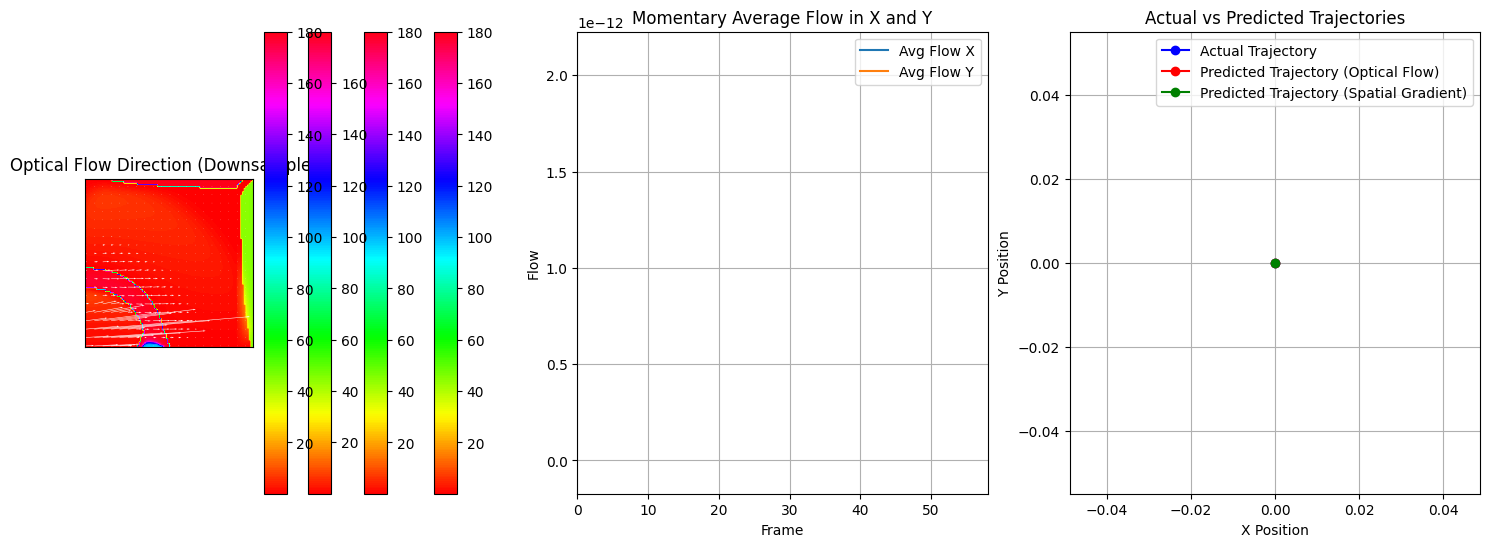

In [215]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Assuming all other functions like calculate_optical_flow and calculate_average_flow are defined above

def calculate_spatial_gradient(matrix_3d):
    gradient_x = np.zeros_like(matrix_3d)
    gradient_y = np.zeros_like(matrix_3d)

    for t in range(matrix_3d.shape[2]):
        gy, gx = np.gradient(matrix_3d[:, :, t])
        gradient_x[:, :, t] = gx
        gradient_y[:, :, t] = gy
    
    return gradient_x, gradient_y
'''
def calculate_predicted_trajectory_from_gradient(avg_grad_x, avg_grad_y, actual_trajectory):
    predicted_trajectory = np.zeros((len(avg_grad_x), 2))
    predicted_trajectory[0] = actual_trajectory[0]  # Start with the initial actual location
    
    for t in range(1, len(avg_grad_x)):
        # Use the actual trajectory's momentary location to predict the next location
        predicted_trajectory[t, 0] = actual_trajectory[t-1, 0] + 1e12 * avg_grad_x[t-1]
        predicted_trajectory[t, 1] = actual_trajectory[t-1, 1] + 1e12 * avg_grad_y[t-1]
    
    return predicted_trajectory
    '''

def calculate_predicted_trajectory_from_gradient(avg_grad_x, avg_grad_y, actual_trajectory):
    # Ensure the predicted trajectory has the same length as actual_trajectory
    predicted_trajectory = np.zeros((len(avg_grad_x), 2))
    predicted_trajectory[0] = actual_trajectory[0]  # Start with the initial actual location
    
    # Iterate through the gradients and predict the trajectory
    for t in range(1, len(avg_grad_x)):
        # Ensure indices don't exceed actual_trajectory bounds
        if t >= len(actual_trajectory):
            break
        predicted_trajectory[t, 0] = actual_trajectory[t-1, 0] + 1e3* avg_grad_x[t-1]
        predicted_trajectory[t, 1] = actual_trajectory[t-1, 1] + 1e3 * avg_grad_y[t-1]
    
    return predicted_trajectory

# Example usage
# Assuming matrix_3d is your 3D matrix with shape (grid_size, grid_size, num_frames)

# Calculate optical flow in x and y directions
flow_x, flow_y = calculate_optical_flow(matrix_3d)

# Calculate the average flow in x and y directions for each frame
avg_flow_x, avg_flow_y = calculate_average_flow(flow_x, flow_y)

# Calculate the spatial gradients
gradient_x, gradient_y = calculate_spatial_gradient(matrix_3d)

# Calculate the average spatial gradients in x and y directions for each frame
avg_grad_x, avg_grad_y = calculate_average_flow(gradient_x, gradient_y)

# Calculate the predicted trajectory from optical flow
predicted_trajectory_optical_flow = calculate_predicted_trajectory(avg_flow_x, avg_flow_y, trajectory)

# Calculate the predicted trajectory from spatial gradients
predicted_trajectory_gradient = calculate_predicted_trajectory_from_gradient(avg_grad_x, avg_grad_y, trajectory)

# Create the figure for the animation
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

def update(t):
    axs[0].clear()
    axs[1].clear()
    axs[2].clear()

    # Plot the optical flow direction with color and arrows
    mag, ang = cv2.cartToPolar(flow_x[t], flow_y[t])
    im = axs[0].imshow(ang * 180 / np.pi / 2, cmap='hsv', origin='lower')
    
    # Downsample the vector field by averaging over 5x5 windows
    window_size = 5
    downsampled_flow_x = flow_x[t].reshape(grid_size // window_size, window_size, -1, window_size).mean(axis=(1, 3))
    downsampled_flow_y = flow_y[t].reshape(grid_size // window_size, window_size, -1, window_size).mean(axis=(1, 3))
    
    # Create a grid for the downsampled quiver plot
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the downsampled quiver plot
    axs[0].quiver(X, Y, downsampled_flow_x, downsampled_flow_y, color='white')
    axs[0].set_title('Optical Flow Direction (Downsampled)')
    axs[0].tick_params(axis='both', which='both', length=0)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].set_xlabel('')
    axs[0].set_ylabel('')

    # Update colorbar (by using the first instance and updating its data)
    if t == 0:
        # Add the colorbar only once
        global cbar
        cbar = fig.colorbar(im, ax=axs[0], orientation='vertical')
    else:
        cbar.update_normal(im)

    # Plot the momentary average optical flow in x and y
    axs[1].plot(avg_flow_x[:t+1], label='Avg Flow X')
    axs[1].plot(avg_flow_y[:t+1], label='Avg Flow Y')

    axs[1].legend()
    axs[1].set_title('Momentary Average Flow in X and Y')
    axs[1].set_xlim(0, len(flow_x) - 1)
    axs[1].set_ylim(np.min([avg_flow_x, avg_flow_y]), np.max([avg_flow_x, avg_flow_y]))
    axs[1].grid(True)
    axs[1].set_xlabel('Frame')
    axs[1].set_ylabel('Flow')

    # Plot the actual vs predicted trajectory using optical flow and spatial gradient
    axs[2].plot(trajectory[:t+1, 0], trajectory[:t+1, 1], 'bo-', label='Actual Trajectory')
    axs[2].plot(predicted_trajectory_optical_flow[:t+1, 0], predicted_trajectory_optical_flow[:t+1, 1], 'ro-', label='Predicted Trajectory (Optical Flow)')
    axs[2].plot(predicted_trajectory_gradient[:t+1, 0], predicted_trajectory_gradient[:t+1, 1], 'go-', label='Predicted Trajectory (Spatial Gradient)')
    axs[2].legend()
    axs[2].set_title('Actual vs Predicted Trajectories')
    axs[2].grid(True)
    axs[2].set_xlabel('X Position')
    axs[2].set_ylabel('Y Position')
    axs[2].axis('equal')

# Initialize the first frame and add the colorbar only once
mag, ang = cv2.cartToPolar(flow_x[0], flow_y[0])
im = axs[0].imshow(ang * 180 / np.pi / 2, cmap='hsv', origin='lower')
cbar = fig.colorbar(im, ax=axs[0], orientation='vertical')

# Create the animation
anim = FuncAnimation(fig, update, frames=len(flow_x), interval=100)

# Save the animation as a GIF
gif_path = 'optical_flow_vs_spatial_gradient_animation.gif'
anim.save(gif_path, writer=PillowWriter(fps=10))

gif_path


In [191]:
np.shape(flow_x)
np.shape(avg_flow_x)

(59,)

'spatial_gradient_vs_trajectory_animation.gif'

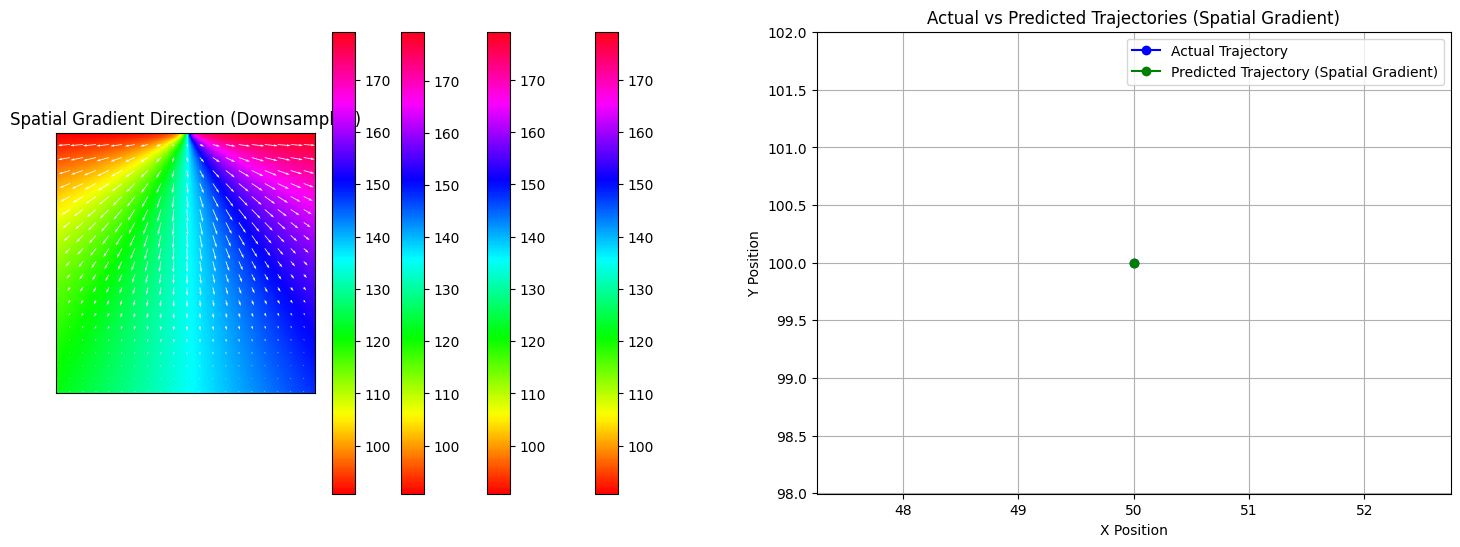

In [188]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def calculate_spatial_gradient(matrix_3d):
    gradient_x = np.zeros_like(matrix_3d)
    gradient_y = np.zeros_like(matrix_3d)

    for t in range(matrix_3d.shape[2]):
        gy, gx = np.gradient(-matrix_3d[:, :, t], axis=(0, 1))  # Calculate the spatial gradient
        gradient_x[:, :, t] = gx
        gradient_y[:, :, t] = gy
    
    return gradient_x, gradient_y

def calculate_predicted_trajectory_from_gradient(avg_grad_x, avg_grad_y, actual_trajectory):
    predicted_trajectory = np.zeros((len(avg_grad_x), 2))
    predicted_trajectory[0] = actual_trajectory[0]  # Start with the initial actual location
    
    for t in range(1, len(avg_grad_x)):
        # Use the actual trajectory's momentary location to predict the next location
        if t >= len(actual_trajectory):
            break
        predicted_trajectory[t, 0] = actual_trajectory[t-1, 0] + 1 * avg_grad_x[t-1]
        predicted_trajectory[t, 1] = actual_trajectory[t-1, 1] + 1 * avg_grad_y[t-1]
    
    return predicted_trajectory

# Example usage
# Assuming matrix_3d is your 3D matrix with shape (grid_size, grid_size, num_frames)

# Calculate the spatial gradients
gradient_x, gradient_y = calculate_spatial_gradient(matrix_3d)

# Calculate the average spatial gradients in x and y directions for each frame
avg_grad_x, avg_grad_y = calculate_average_flow(gradient_x, gradient_y)  # Using the existing calculate_average_flow function

# Calculate the predicted trajectory from spatial gradients
predicted_trajectory_gradient = calculate_predicted_trajectory_from_gradient(avg_grad_x, avg_grad_y, trajectory)

# Create the figure for the animation
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

def update(t):
    axs[0].clear()
    axs[1].clear()

    # Plot the spatial gradient direction with color and arrows
    current_matrix = matrix_3d[:, :, t]
    gy, gx = np.gradient(-current_matrix, axis=(0, 1))  # Spatial gradient at this frame
    mag, ang = cv2.cartToPolar(gx, gy)
    im = axs[0].imshow(ang * 180 / np.pi / 2, cmap='hsv', origin='lower')
    
    # Downsample the vector field by averaging over 5x5 windows
    window_size = 5
    downsampled_gx = gx.reshape(grid_size // window_size, window_size, -1, window_size).mean(axis=(1, 3))
    downsampled_gy = gy.reshape(grid_size // window_size, window_size, -1, window_size).mean(axis=(1, 3))
    
    # Create a grid for the downsampled quiver plot
    X, Y = np.meshgrid(np.arange(0, grid_size, window_size), np.arange(0, grid_size, window_size))
    
    # Plot the downsampled quiver plot
    axs[0].quiver(X, Y, downsampled_gx, downsampled_gy, color='white')
    axs[0].set_title('Spatial Gradient Direction (Downsampled)')
    axs[0].tick_params(axis='both', which='both', length=0)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].set_xlabel('')
    axs[0].set_ylabel('')

    # Update colorbar (by using the first instance and updating its data)
    if t == 0:
        global cbar
        cbar = fig.colorbar(im, ax=axs[0], orientation='vertical')
    else:
        cbar.update_normal(im)

    # Plot the actual vs predicted trajectory using spatial gradient
    axs[1].plot(trajectory[:t+1, 0], trajectory[:t+1, 1], 'bo-', label='Actual Trajectory')
    axs[1].plot(predicted_trajectory_gradient[:t+1, 0], predicted_trajectory_gradient[:t+1, 1], 'go-', label='Predicted Trajectory (Spatial Gradient)')
    axs[1].legend()
    axs[1].set_title('Actual vs Predicted Trajectories (Spatial Gradient)')
    axs[1].grid(True)
    axs[1].set_xlabel('X Position')
    axs[1].set_ylabel('Y Position')
    axs[1].axis('equal')

# Initialize the first frame and add the colorbar only once
current_matrix = matrix_3d[:, :, 0]
gy, gx = np.gradient(-current_matrix, axis=(0, 1))
mag, ang = cv2.cartToPolar(gx, gy)
im = axs[0].imshow(ang * 180 / np.pi / 2, cmap='hsv', origin='lower')
cbar = fig.colorbar(im, ax=axs[0], orientation='vertical')

# Create the animation
anim = FuncAnimation(fig, update, frames=matrix_3d.shape[2], interval=100)

# Save the animation as a GIF
gif_path = 'spatial_gradient_vs_trajectory_animation.gif'
anim.save(gif_path, writer=PillowWriter(fps=10))

gif_path


In [ ]:
# show example that the frequency of gasian changes (changes in the sigma)

In [ ]:
# show example of standing waves (frequency/sigma changes but center of the bomp do not move)

In [ ]:
# show an example that there is a spairal wave in sapce that changes it's location

In [ ]:
# show an example that sprial only happen in time not space (I think I alreayd have it) 

In [ ]:
# show a scenario with mutiple gaussian ?

In [ ]:
#Show an example that I can have spatially complex wave but temrpoaly tracktable (non-choatic)

In [ ]:
# show real data
